# 03 · Red convolucional 1D (PyTorch)

**Objetivo:** ver si una CNN que aprende la morfología completa del latido (y recibe las RR en
la cabeza) supera al baseline XGBoost (F1 macro 0.493 en validación por paciente).

**Protocolo (el mismo rigor que el baseline)**

- Solo DS1. **DS2 no se carga en este notebook.**
- **Mismos 5 folds externos por paciente** que el baseline (`train.patient_folds`).
- **Early stopping sin tocar el fold externo:** dentro de cada fold de entrenamiento se separa
  1/4 de los pacientes (`StratifiedGroupKFold`) y se detiene por F1 macro en ellos (paciencia 7).
- Scaler de RR y pesos de clase: solo con los pacientes de entrenamiento.
- **Cada variante se corre con 2 semillas** (la semilla cambia inicialización *y* qué pacientes
  quedan para el early stopping). La elegida se corre con 3.

Arquitectura, pérdida, optimizador y batch: los de la especificación del proyecto
(`src/ecg/models/cnn.py`). Entrenamiento en GPU de Apple (MPS), ~140 s por validación cruzada.

> Proyecto educativo y de investigación. No es un dispositivo médico.

In [1]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ecg import config
from ecg.data import rhythm_at
from ecg.evaluate import confusion, per_class_metrics, per_record_metrics, plot_confusion, summary
from ecg.features import build_features
from ecg.models.baseline import BaselineClassifier
from ecg.models.cnn import CNNClassifier, CNNConfig, pick_device
from ecg.segment import load_split
from ecg.train import BASELINE_CHOICE, cross_validate, cross_validate_cnn, fit_final_cnn

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
FIG_DIR = config.REPORTS_DIR / "figures"
RUNS = config.DATA_DIR / "runs" / "cnn"   # caché de predicciones out-of-fold (borrar para recalcular)
RUNS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.precision", 3)

ds1 = load_split("ds1")
X, F, y, groups, symbols = ds1["X"], ds1["F"], ds1["y"], ds1["record"], ds1["symbol"]
print("dispositivo:", pick_device("auto"))

dispositivo: mps


## 1. Referencia: baseline con los mismos folds

In [2]:
Zb, _ = build_features(X, F, BASELINE_CHOICE["feature_set"])
make_baseline = lambda: BaselineClassifier(kind=BASELINE_CHOICE["kind"], params=BASELINE_CHOICE["params"],
                                           feature_set=BASELINE_CHOICE["feature_set"],
                                           weight_power=BASELINE_CHOICE["weight_power"])
base_cv = cross_validate(make_baseline, Zb, y, groups)
base = summary(y, base_cv["pred"])
print(f"baseline F1 macro: {base['macro_f1']:.3f}")

baseline F1 macro: 0.493


## 2. Antes de experimentar: ¿el early stopping funciona?

La primera corrida mostró que la F1 macro de validación **oscilaba mucho entre épocas**. Para
entender por qué, se entrenaron 25 épocas midiendo en cada una la validación interna y el fold
externo, con varios estabilizadores, en los folds 0 y 3
(`notebooks/early_stopping_check.py`, ~15 min de GPU; resultados guardados):

In [3]:
print((config.REPORTS_DIR / "cnn_early_stopping_check.txt").read_text())

fold 0 base
outer_f1 épocas 6-25: media 0.364  sd 0.029  | inner_f1 sd 0.031 | salto medio entre épocas 0.030
corr outer_f1 vs inner_f1: 0.57 | vs -inner_loss: 0.09
epoch by inner_f1: 19 -> outer 0.375 | epoch by inner_loss: 1 -> outer 0.353 | max outer 0.411
fold 3 base
outer_f1 épocas 6-25: media 0.552  sd 0.068  | inner_f1 sd 0.057 | salto medio entre épocas 0.056
corr outer_f1 vs inner_f1: 0.25 | vs -inner_loss: 0.27
epoch by inner_f1: 1 -> outer 0.534 | epoch by inner_loss: 5 -> outer 0.607 | max outer 0.654
fold 0 lr3e-4
outer_f1 épocas 6-25: media 0.362  sd 0.038  | inner_f1 sd 0.035 | salto medio entre épocas 0.044
corr outer_f1 vs inner_f1: 0.74 | vs -inner_loss: -0.13
epoch by inner_f1: 6 -> outer 0.423 | epoch by inner_loss: 16 -> outer 0.319 | max outer 0.423
fold 3 lr3e-4
outer_f1 épocas 6-25: media 0.521  sd 0.075  | inner_f1 sd 0.065 | salto medio entre épocas 0.098
corr outer_f1 vs inner_f1: 0.34 | vs -inner_loss: 0.21
epoch by inner_f1: 7 -> outer 0.475 | epoch by inne

**Conclusiones:**

- **La F1 en pacientes externos oscila tanto como la interna** (fold 3 sin cambios: desvío 0.07
  entre épocas, saltos medios de 0.06). No es solo un criterio de parada ruidoso: las predicciones
  de la red sobre pacientes nuevos cambian mucho de una época a otra.
- **Bajar el learning rate, weight decay o aumento de datos no la estabilizan.**
- **EMA de pesos sí estabiliza** (saltos de 0.009 y correlación interna/externa de 0.84–0.96),
  pero revela algo más importante: con la curva suavizada, la F1 externa **baja con las épocas**
  (fold 3: 0.33 de media con EMA contra 0.55 sin EMA). La red se especializa en los ~14 pacientes
  de entrenamiento y generaliza peor cuanto más entrena.
- Decisión: se mantiene el protocolo de la especificación (F1 macro, paciencia 7) y se compensa
  el ruido **corriendo varias semillas**. Una sola semilla no alcanza para comparar variantes.

## 3. Experimentos

In [4]:
results = {}

def run(name, seeds=(42, 7), **cfg_kw):
    """Validación cruzada con caché en data/runs/cnn/<name>__s<seed>.npz."""
    rows = []
    for seed in seeds:
        cfg = CNNConfig(seed=seed, **cfg_kw)
        npz, meta_path = RUNS / f"{name}__s{seed}.npz", RUNS / f"{name}__s{seed}.json"
        if npz.exists():
            proba = np.load(npz)["proba"]
            meta = json.loads(meta_path.read_text())
        else:
            t0 = time.time()
            cv = cross_validate_cnn(cfg, X, F, y, groups)
            proba = cv["proba"]
            meta = {k: cv[k] for k in ["best_epochs", "histories", "inner_train_records"]}
            meta["seconds"] = round(time.time() - t0)
            np.savez_compressed(npz, proba=proba, fold=cv["fold"])
            meta_path.write_text(json.dumps(meta))
        pred = np.asarray(config.CLASSES)[proba.argmax(axis=1)]
        results[(name, seed)] = {"proba": proba, "pred": pred, **meta}
        rows.append({"experimento": name, "semilla": seed, **cfg_kw, **summary(y, pred),
                     "épocas": meta["best_epochs"]})
    return pd.DataFrame(rows)

COLS = ["macro_f1", "N_F1", "S_Se", "S_+P", "S_F1", "V_Se", "V_+P", "V_F1", "F_F1"]

def by_experiment(df):
    g = df.groupby("experimento", sort=False)
    t = g[COLS].mean().round(3)
    t.insert(1, "macro_f1_sd", g["macro_f1"].std().round(3))
    t.insert(0, "semillas", g.size())
    return t.sort_values("macro_f1", ascending=False, kind="stable")

log = []

### 3.1 ¿Sirven las features RR?

Referencia de la especificación (RR absolutas + cocientes) contra CNN sin RR y con solo cocientes.

In [5]:
exp_rr = pd.concat([
    run("rr_all", rr="all", balance="weights"),
    run("rr_none", rr="none", balance="weights"),
    run("rr_ratios", rr="ratios", balance="weights"),
])
log.append(exp_rr)
t = by_experiment(exp_rr)
best_rr = exp_rr.loc[exp_rr.experimento == t.index[0], "rr"].iloc[0]
print("mejor configuración de RR:", best_rr)
display(exp_rr[["experimento", "semilla", "macro_f1", "S_Se", "S_+P", "V_+P", "épocas"]])
t

mejor configuración de RR: ratios


,experimento,semilla,macro_f1,S_Se,S_+P,V_+P,épocas
0,rr_all,42,0.438,0.394,0.173,0.496,"[5, 6, 6, 1, 5]"
1,rr_all,7,0.423,0.420,0.107,0.496,"[6, 2, 6, 7, 5]"
0,rr_none,42,0.413,0.311,0.112,0.481,"[9, 7, 6, 9, 11]"
1,rr_none,7,0.340,0.130,0.087,0.270,"[8, 3, 7, 7, 15]"
0,rr_ratios,42,0.432,0.357,0.196,0.467,"[6, 3, 3, 7, 12]"
1,rr_ratios,7,0.448,0.397,0.253,0.430,"[6, 3, 4, 4, 11]"


,semillas,macro_f1,macro_f1_sd,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,F_F1
experimento,,,,,,,,,,,
rr_ratios,2,0.440,0.011,0.878,0.377,0.225,0.281,0.882,0.448,0.594,0.008
rr_all,2,0.430,0.010,0.887,0.407,0.140,0.206,0.854,0.496,0.627,0.002
rr_none,2,0.376,0.052,0.865,0.221,0.100,0.135,0.817,0.375,0.505,0.001


**Conclusiones:**

- **Las RR son necesarias.** Sin ellas, la F1 macro baja a 0.376 y la S casi desaparece
  (Se 0.22, +P 0.10). Además la red se vuelve más inestable: el desvío entre semillas es 0.052,
  contra ~0.01 con RR. Confirma lo que anticipaba la guía: sin timing, la S no se detecta.
- **Solo cocientes (0.440 ± 0.011) vs RR completas (0.430 ± 0.010):** la diferencia está dentro
  del ruido. Con la regla fijada de antemano gana `ratios`, que además mejora la +P de S (0.23
  contra 0.14). A diferencia del baseline, acá los cocientes quedan arriba: coincide con la
  hipótesis del EDA, pero no hay evidencia fuerte en ninguna dirección.

### 3.2 Pesos de clase vs `WeightedRandomSampler`

In [6]:
exp_bal = pd.concat([exp_rr[exp_rr.rr == best_rr],
                     run(f"sampler_{best_rr}", rr=best_rr, balance="sampler")])
log.append(exp_bal.iloc[2:])
t = by_experiment(exp_bal)
best_balance = exp_bal.loc[exp_bal.experimento == t.index[0], "balance"].iloc[0]
print("mejor balanceo:", best_balance)
t

mejor balanceo: weights


,semillas,macro_f1,macro_f1_sd,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,F_F1
experimento,,,,,,,,,,,
rr_ratios,2,0.440,0.011,0.878,0.377,0.225,0.281,0.882,0.448,0.594,0.008
sampler_ratios,2,0.414,0.000,0.847,0.417,0.173,0.234,0.859,0.432,0.572,0.001


**Conclusiones:**

- `WeightedRandomSampler` (0.414, igual con las dos semillas) rinde peor que la pérdida ponderada
  (0.440). Sobremuestrear repite muchas veces los mismos pocos latidos S y F de pocos pacientes:
  sube la Se de S (0.42), pero cae la F1 de N (0.847) por las falsas alarmas.

### 3.3 Aumento de datos

Ruido gaussiano (σ = 0.05), escala de amplitud (0.8–1.2) y desplazamiento de ±5 muestras
(±14 ms). Además, **inversión de polaridad** aleatoria: el baseline confundió el bloqueo de rama
del registro 207 (QRS invertido) con V.

In [7]:
base_kw = {"rr": best_rr, "balance": best_balance}
exp_aug = pd.concat([
    run(f"aug_{best_rr}_{best_balance}", augment=True, **base_kw),
    run(f"aug_invert_{best_rr}_{best_balance}", augment=True, invert=True, **base_kw),
])
log.append(exp_aug)
by_experiment(exp_aug)

,semillas,macro_f1,macro_f1_sd,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,F_F1
experimento,,,,,,,,,,,
aug_ratios_weights,2,0.452,0.027,0.897,0.390,0.274,0.321,0.894,0.437,0.586,0.005
aug_invert_ratios_weights,2,0.444,0.038,0.887,0.339,0.158,0.215,0.899,0.544,0.670,0.002


### 3.4 Tabla general y elección

In [8]:
all_runs = pd.concat(log, ignore_index=True)
board = by_experiment(all_runs)
chosen = board.index[0]
chosen_kw = {k: all_runs.loc[all_runs.experimento == chosen, k].iloc[0]
             for k in ["rr", "balance", "augment", "invert"] if k in all_runs}
chosen_kw = {k: (bool(v) if k in ["augment", "invert"] else v) for k, v in chosen_kw.items()
             if not (isinstance(v, float) and np.isnan(v))}
print("elegida:", chosen, chosen_kw)
board

elegida: aug_ratios_weights {'rr': 'ratios', 'balance': 'weights', 'augment': True}


,semillas,macro_f1,macro_f1_sd,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,F_F1
experimento,,,,,,,,,,,
aug_ratios_weights,2,0.452,0.027,0.897,0.390,0.274,0.321,0.894,0.437,0.586,0.005
aug_invert_ratios_weights,2,0.444,0.038,0.887,0.339,0.158,0.215,0.899,0.544,0.670,0.002
rr_ratios,2,0.440,0.011,0.878,0.377,0.225,0.281,0.882,0.448,0.594,0.008
rr_all,2,0.430,0.010,0.887,0.407,0.140,0.206,0.854,0.496,0.627,0.002
sampler_ratios,2,0.414,0.000,0.847,0.417,0.173,0.234,0.859,0.432,0.572,0.001
rr_none,2,0.376,0.052,0.865,0.221,0.100,0.135,0.817,0.375,0.505,0.001


**Conclusiones:**

- **Aumento de datos es la mejor variante (0.452 ± 0.027).** Ruido, escala y desplazamiento
  mejoran la +P de S (0.27 contra 0.23 sin aumento).
- **La inversión de polaridad no cumplió su objetivo.** Sube la +P de V (0.54, la mejor de todas)
  pero hunde la de S (0.16). Y no arregla el bloqueo de rama del 207 (sección 4.2): la hipótesis
  queda refutada.
- Las 4 mejores variantes están entre 0.430 y 0.452, una diferencia comparable al desvío entre
  semillas (0.01–0.04). **Ninguna variante de la CNN alcanza al baseline (0.493).**
- Elegida: `aug_ratios_weights` (cocientes RR + pérdida ponderada + aumento de datos).

## 4. Variante elegida: tercera semilla y comparación con el baseline

Además del baseline entrenado con todos los pacientes de cada fold, se entrena el baseline con
**los mismos pacientes que vio la CNN** (sin el cuarto reservado para early stopping), para una
comparación en igualdad de condiciones.

In [9]:
final = run(chosen, seeds=(42, 7, 123), **chosen_kw)
all_runs = pd.concat([all_runs[all_runs.experimento != chosen], final], ignore_index=True)
all_runs.drop(columns=["épocas"]).to_csv(config.REPORTS_DIR / "cnn_experiments.csv", index=False)

# Baseline con los mismos pacientes de entrenamiento que la CNN (semilla 42)
inner = results[(chosen, 42)]["inner_train_records"]
proba_b75 = np.zeros((len(y), 4), dtype=np.float32)
from ecg.train import patient_folds
for k, (tr, va) in enumerate(patient_folds(groups)):
    keep = tr[np.isin(groups[tr], inner[k])]
    proba_b75[va] = make_baseline().fit(Zb[keep], y[keep]).predict_proba(Zb[va])
pred_b75 = np.asarray(config.CLASSES)[proba_b75.argmax(axis=1)]

# Ensamble de las 3 semillas (promedio de probabilidades), como referencia
proba_ens = np.mean([results[(chosen, s)]["proba"] for s in (42, 7, 123)], axis=0)
pred_ens = np.asarray(config.CLASSES)[proba_ens.argmax(axis=1)]

cmp_rows = {"Baseline XGBoost (todos los pacientes del fold)": summary(y, base_cv["pred"]),
            "Baseline XGBoost (mismos pacientes que la CNN)": summary(y, pred_b75)}
for s in (42, 7, 123):
    cmp_rows[f"CNN semilla {s}"] = summary(y, results[(chosen, s)]["pred"])
cmp = pd.DataFrame(cmp_rows).T[COLS]
cmp.loc["CNN media ± sd (3 semillas)"] = cmp.loc[[f"CNN semilla {s}" for s in (42, 7, 123)]].mean()
cmp.loc["CNN sd entre semillas"] = cmp.loc[[f"CNN semilla {s}" for s in (42, 7, 123)]].std()
cmp.loc["CNN ensamble 3 semillas"] = pd.Series(summary(y, pred_ens))[COLS]
cmp

,macro_f1,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,F_F1
Baseline XGBoost (todos los pacientes del fold),0.493,0.947,0.319,0.445,0.372,0.914,0.509,0.654,0.000e+00
Baseline XGBoost (mismos pacientes que la CNN),0.474,0.945,0.331,0.280,0.304,0.907,0.504,0.648,0.000e+00
CNN semilla 42,0.471,0.880,0.420,0.324,0.366,0.912,0.484,0.633,6.561e-03
CNN semilla 7,0.433,0.914,0.361,0.224,0.277,0.876,0.389,0.539,3.320e-03
CNN semilla 123,0.486,0.893,0.296,0.374,0.330,0.900,0.597,0.718,6.373e-04
CNN media ± sd (3 semillas),0.463,0.896,0.359,0.307,0.324,0.896,0.490,0.630,3.506e-03
CNN sd entre semillas,0.027,0.017,0.062,0.076,0.045,0.019,0.104,0.090,2.966e-03
CNN ensamble 3 semillas,0.480,0.909,0.334,0.332,0.333,0.905,0.539,0.676,9.304e-04


**Conclusiones: la comparación justa cambia la lectura**

- **CNN: 0.463 ± 0.027 (3 semillas, rango 0.433–0.486). Baseline: 0.493.** A primera vista la
  CNN pierde por 0.03.
- **Pero la CNN entrena con 1/4 menos de pacientes** (los reserva para el early stopping). El
  baseline entrenado con **los mismos pacientes** baja a **0.474**. En igualdad de condiciones la
  diferencia es 0.011, menos de la mitad del desvío entre semillas: **no hay evidencia de que
  uno sea mejor que el otro.** Dos tercios de la ventaja aparente del baseline venían de ver más
  pacientes, no del tipo de modelo.
- **Perfiles distintos:** la CNN detecta más S (Se 0.36 contra 0.32), pero da muchas más falsas
  alarmas (F1 de N 0.896 contra 0.947; +P de S 0.31 contra 0.45).
- **La CNN es mucho menos predecible:** la +P de V varía 0.10 entre semillas (0.39 a 0.60).
- **Promediar las 3 semillas (ensamble) sube a 0.480** y logra la mejor F1 de V de todas
  (0.676, contra 0.654 del baseline): es la señal de que el problema es la varianza. Queda
  como extensión, no como modelo elegido: no estaba en el plan de experimentos.

### 4.1 Curvas de entrenamiento

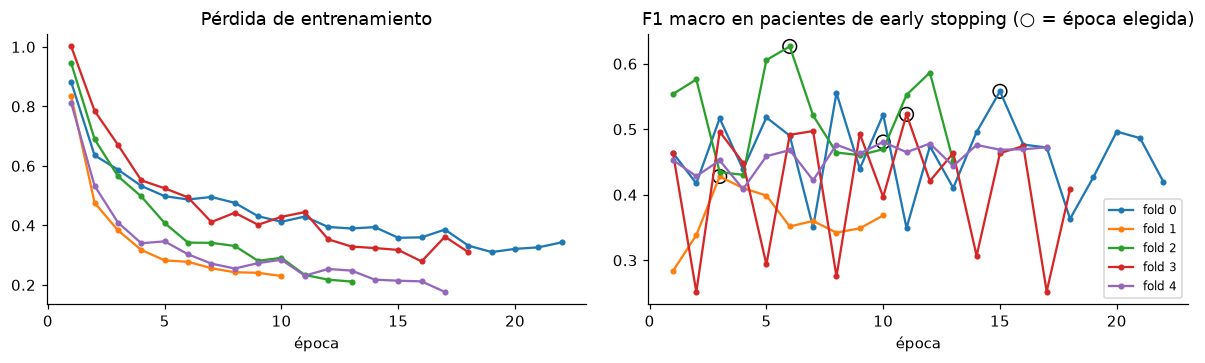

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for k, h in enumerate(results[(chosen, 42)]["histories"]):
    h = pd.DataFrame(h)
    axes[0].plot(h.epoch, h.train_loss, marker=".", label=f"fold {k}")
    axes[1].plot(h.epoch, h.val_macro_f1, marker=".", label=f"fold {k}")
    best = results[(chosen, 42)]["best_epochs"][k]
    axes[1].scatter([best], [float(h.loc[h.epoch == best, "val_macro_f1"].iloc[0])], s=80,
                    facecolors="none", edgecolors="k")
axes[0].set(title="Pérdida de entrenamiento", xlabel="época")
axes[1].set(title="F1 macro en pacientes de early stopping (○ = época elegida)", xlabel="época")
axes[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "cnn_training_curves.png")

### 4.2 Matriz de confusión y errores por paciente

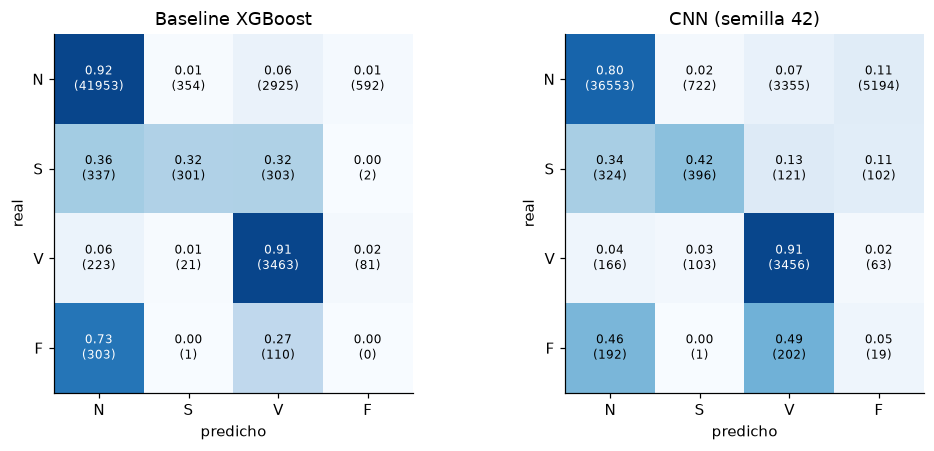

In [11]:
pred_cnn = results[(chosen, 42)]["pred"]
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
plot_confusion(confusion(y, base_cv["pred"], normalize=True), axes[0], "Baseline XGBoost",
               counts=confusion(y, base_cv["pred"]))
plot_confusion(confusion(y, pred_cnn, normalize=True), axes[1], "CNN (semilla 42)",
               counts=confusion(y, pred_cnn))
fig.tight_layout(); fig.savefig(FIG_DIR / "cnn_vs_baseline_confusion.png")

In [12]:
cases = [(207, "N", "V", "LBBB invertido"), (203, "N", "V", "FA/flutter + ruido"),
         (201, "N", "S", "fibrilación auricular"), (209, "S", "N", "rachas de SVTA"),
         (208, "F", "N", "fusión"), (215, "V", "N", "V no detectados")]
rows = []
for rec, real, pr, desc in cases:
    m = (groups == rec) & (y == real)
    row = {"registro": rec, "error": f"{real}→{pr}", "caso": desc, "latidos de la clase real": int(m.sum()),
           "baseline": int((base_cv["pred"][m] == pr).sum())}
    for s in (42, 7, 123):
        row[f"CNN s{s}"] = int((results[(chosen, s)]["pred"][m] == pr).sum())
    rows.append(row)
errors = pd.DataFrame(rows).set_index("registro")
errors

,error,caso,latidos de la clase real,baseline,CNN s42,CNN s7,CNN s123
registro,,,,,,,
207,N→V,LBBB invertido,1542,1400,983,1429,1413
203,N→V,FA/flutter + ruido,2527,1320,271,618,309
201,N→S,fibrilación auricular,1633,240,181,87,63
209,S→N,rachas de SVTA,383,237,198,185,229
208,F→N,fusión,372,267,160,176,273
215,V→N,V no detectados,164,149,42,21,19


In [13]:
m = (groups == 209) & (y == "S")
rh = rhythm_at(209, ds1["r_peak"][m])
pd.DataFrame({"ritmo": rh, "baseline": base_cv["pred"][m] == "S", "CNN s42": pred_cnn[m] == "S"}) \
  .groupby("ritmo").agg(latidos=("baseline", "size"), Se_baseline=("baseline", "mean"),
                        Se_CNN=("CNN s42", "mean"))

,latidos,Se_baseline,Se_CNN
ritmo,,,
(N,124,0.710,0.903
(SVTA,259,0.224,0.278


,baseline,CNN (media 3 semillas),diferencia
record,,,
201,496,447.667,-48.333
209,249,213.667,-35.333
124,65,48.000,-17.000
118,99,90.000,-9.000
220,18,11.000,-7.000
122,0,0.000,0.000
205,15,24.667,9.667
114,37,50.667,13.667
116,5,29.000,24.000


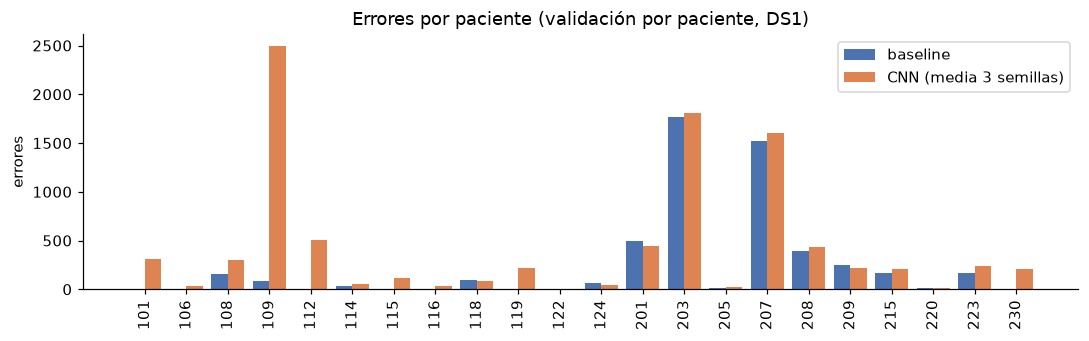

In [14]:
per_rec = pd.DataFrame({
    "baseline": per_record_metrics(y, base_cv["pred"], groups)["errores"],
    "CNN (media 3 semillas)": np.mean([per_record_metrics(y, results[(chosen, s)]["pred"], groups)["errores"]
                                       for s in (42, 7, 123)], axis=0),
})
per_rec["diferencia"] = per_rec["CNN (media 3 semillas)"] - per_rec["baseline"]
fig, ax = plt.subplots(figsize=(10, 3.2))
xs = np.arange(len(per_rec))
ax.bar(xs - 0.2, per_rec["baseline"], 0.4, label="baseline", color="#4C72B0")
ax.bar(xs + 0.2, per_rec["CNN (media 3 semillas)"], 0.4, label="CNN (media 3 semillas)", color="#DD8452")
ax.set_xticks(xs, per_rec.index.astype(str), rotation=90); ax.set_ylabel("errores")
ax.set_title("Errores por paciente (validación por paciente, DS1)"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "cnn_vs_baseline_records.png")
per_rec.sort_values("diferencia")

In [15]:
# Tipo de error dominante en los pacientes donde la CNN empeora, por semilla
rows = []
for rec in [109, 112, 101, 119, 230, 115, 108]:
    m = groups == rec
    row = {"registro": rec}
    for s in (42, 7, 123):
        p = results[(chosen, s)]["pred"][m]
        e = pd.Series([f"{a}({sy})→{b}" for a, sy, b in zip(y[m], symbols[m], p) if a != b]).value_counts()
        row[f"CNN s{s}"] = f"{e.index[0]}: {e.iloc[0]}" if len(e) else "—"
    eb = pd.Series([f"{a}({sy})→{b}" for a, sy, b in zip(y[m], symbols[m], base_cv["pred"][m]) if a != b]).value_counts()
    row["baseline"] = f"{eb.index[0]}: {eb.iloc[0]}" if len(eb) else "—"
    rows.append(row)
pd.DataFrame(rows).set_index("registro")

,CNN s42,CNN s7,CNN s123,baseline
registro,,,,
109,N(L)→F: 2292,N(L)→V: 2488,N(L)→F: 2376,N(L)→V: 47
112,N(N)→V: 1456,S(A)→N: 1,N(N)→S: 3,S(A)→V: 2
101,N(N)→V: 2,N(N)→F: 11,N(N)→F: 898,S(A)→N: 2
119,N(N)→S: 21,N(N)→S: 530,N(N)→S: 95,—
230,N(N)→F: 412,N(N)→F: 63,N(N)→F: 116,N(N)→S: 1
115,N(N)→S: 178,N(N)→S: 79,N(N)→S: 92,N(N)→S: 3
108,N(N)→V: 369,N(N)→V: 227,N(N)→V: 109,N(N)→V: 148


In [16]:
# Bloqueo de rama izquierda y falsas alarmas en todas las variantes
rows = [{"modelo": "baseline XGBoost", "semilla": "—",
         "LBBB 109 bien (%)": 100 * (base_cv["pred"][(groups == 109) & (symbols == "L")] == "N").mean(),
         "LBBB 207 bien (%)": 100 * (base_cv["pred"][(groups == 207) & (symbols == "L")] == "N").mean(),
         "N→F": int(((y == "N") & (base_cv["pred"] == "F")).sum()),
         "N→V": int(((y == "N") & (base_cv["pred"] == "V")).sum())}]
for (name, s), r in results.items():
    p = r["pred"]
    rows.append({"modelo": f"CNN {name}", "semilla": s,
                 "LBBB 109 bien (%)": 100 * (p[(groups == 109) & (symbols == "L")] == "N").mean(),
                 "LBBB 207 bien (%)": 100 * (p[(groups == 207) & (symbols == "L")] == "N").mean(),
                 "N→F": int(((y == "N") & (p == "F")).sum()), "N→V": int(((y == "N") & (p == "V")).sum())})
pd.DataFrame(rows).round(1)

,modelo,semilla,LBBB 109 bien (%),LBBB 207 bien (%),N→F,N→V
0,baseline XGBoost,—,96.9,4.0,592,2925
1,CNN rr_all,42,0.3,1.0,3545,2790
2,CNN rr_all,7,0.2,0.5,2759,3094
3,CNN rr_none,42,15.9,0.5,3535,2909
4,CNN rr_none,7,0.0,0.3,1787,8115
5,CNN rr_ratios,42,0.6,1.2,6583,3550
6,CNN rr_ratios,7,0.4,0.8,2024,4111
7,CNN sampler_ratios,42,54.9,2.1,7448,4899
8,CNN sampler_ratios,7,90.4,1.7,3014,3051
9,CNN aug_ratios_weights,42,0.2,1.4,5194,3355


**Conclusiones: dónde gana y dónde pierde la CNN**

La CNN **mejora** justo en los casos donde la morfología completa y el ruido importan:

| Caso | Baseline | CNN (3 semillas) |
|---|---|---|
| 203: N→V durante FA/flutter con ruido | 1 320 | 271 / 618 / 309 |
| 201: N→S durante fibrilación auricular | 240 | 181 / 87 / 63 |
| 215: V no detectados (el error más grave, RISK-01) | 149 | 42 / 21 / 19 |
| 209: Se de S en ritmo normal | 0.71 | 0.90 (semilla 42) |

Y **empeora** en tres cosas que la F1 agregada esconde:

1. **Bloqueo de rama izquierda: la CNN elegida falla en los dos pacientes.** El baseline acierta
   el 96.9 % de los latidos L del 109; la CNN elegida, 0.1–0.2 % (los clasifica como F o V). En
   las 11 corridas con pérdida ponderada, el LBBB del 109 queda en ≤ 1 %, salvo una sin RR
   (15.9 %). **Solo el `WeightedRandomSampler` lo reconoce en parte (55 % y 90 %)**, a cambio de
   más falsas F (hasta 7 448). Cuando el 109 está en validación, el único LBBB de entrenamiento es
   el del 207, con otra morfología. Las features resumidas del baseline sí generalizan al 109,
   pero el LBBB del 207 no lo reconoce nadie: ninguna corrida pasa del 2.1 %, ni siquiera con
   inversión de polaridad. El 207 difiere en más que el signo.
2. **Falsas F:** la semilla 42 marca 5 194 latidos N como F, contra 592 del baseline. El peso de
   la clase F (~30 veces el de N) lleva a la red a llamar "fusión" a cualquier N inusual (109,
   230, 101).
3. **Fallas catastróficas que dependen de la semilla.** En el 112, 1 456 N→V con la semilla 42 y
   casi ninguno con las otras dos. En el 101, 898 N→F solo con la 123. En el 119, 530 N→S solo con
   la 7. **Para un dispositivo médico, que el rendimiento en un paciente dependa de la
   semilla es un riesgo en sí mismo** (RISK-05): se documenta en el análisis de riesgo.

La SVTA del 209 casi no mejora (Se 0.22 → 0.28): como el feature RR es el mismo, la limitación
estructural sigue ahí.

## 5. Modelo para la Fase 5

In [17]:
cnn_mean = cmp.loc["CNN media ± sd (3 semillas)", "macro_f1"]
cnn_sd = cmp.loc["CNN sd entre semillas", "macro_f1"]
primary = "cnn" if cnn_mean > base["macro_f1"] else "baseline_xgb"
selection = {
    "rule": "Mayor F1 macro out-of-fold en DS1 (5 folds por paciente). Fijada antes de ver DS2.",
    "primary_model": primary,
    "comparison_model": "baseline_xgb" if primary == "cnn" else "cnn",
    "cv_macro_f1": {"baseline_xgb": round(base["macro_f1"], 4),
                    "cnn_mean_3_seeds": round(float(cnn_mean), 4), "cnn_sd": round(float(cnn_sd), 4)},
    "cnn_config": chosen_kw,
    "note": "Ambos modelos se evalúan una sola vez en DS2; el primario se declara acá.",
}
(config.REPORTS_DIR / "model_selection.json").write_text(json.dumps(selection, indent=2))
selection

{'rule': 'Mayor F1 macro out-of-fold en DS1 (5 folds por paciente). Fijada antes de ver DS2.',
 'primary_model': 'baseline_xgb',
 'comparison_model': 'cnn',
 'cv_macro_f1': {'baseline_xgb': 0.4931,
  'cnn_mean_3_seeds': 0.4634,
  'cnn_sd': 0.0271},
 'cnn_config': {'rr': 'ratios', 'balance': 'weights', 'augment': True},
 'note': 'Ambos modelos se evalúan una sola vez en DS2; el primario se declara acá.'}

In [18]:
t0 = time.time()
path = fit_final_cnn(CNNConfig(seed=42, **chosen_kw), ds1,
                     cv_summary={"n_folds": 5, "grouping": "record", "seeds": [42, 7, 123],
                                 **cmp.loc["CNN media ± sd (3 semillas)"].to_dict(),
                                 "macro_f1_sd_seeds": float(cnn_sd)})
print(f"modelo final -> {path.name} ({time.time() - t0:.0f} s)")

# Latencia en CPU (así corre la API en Docker): un registro de 30 min ≈ 2 000 latidos
cpu_model = CNNClassifier.load(path, device="cpu")
t0 = time.time(); cpu_model.predict_proba(X[:2000], F[:2000]); dt = time.time() - t0
n_params = sum(p.numel() for p in cpu_model.model_.parameters())
print(f"parámetros: {n_params:,} | archivo: {path.stat().st_size / 1024:.0f} KB | "
      f"2 000 latidos en CPU: {dt * 1000:.0f} ms")

modelo final -> cnn.pt (64 s)


parámetros: 44,356 | archivo: 182 KB | 2 000 latidos en CPU: 1323 ms


## Resumen

| | F1 macro (validación por paciente, DS1) |
|---|---|
| Baseline XGBoost | **0.493** |
| Baseline XGBoost con los mismos pacientes que la CNN | 0.474 |
| CNN elegida (cocientes RR + pesos + aumento), 3 semillas | 0.463 ± 0.027 |
| Ensamble de las 3 semillas (referencia) | 0.480 |

**Modelo primario para la Fase 5: baseline XGBoost**, por la regla fijada de antemano (mayor F1
macro). La CNN (`models/cnn.pt`, 44 356 parámetros, 182 KB, ~1 s para 2 000 latidos en CPU) se
evalúa en DS2 **como comparación**. Ambos se evalúan una sola vez; la elección quedó registrada
en `reports/model_selection.json` antes de tocar DS2.

**Qué se aprendió**

1. *"Si la CNN no le gana al baseline, eso también es un hallazgo válido."* Acá, además, se sabe
   **por qué**: la diferencia aparente viene de pacientes de entrenamiento y varianza, no de la
   capacidad del modelo.
2. **Con 22 pacientes, la unidad de análisis es el paciente, no el latido.** Las fallas de la
   CNN se concentran en pacientes puntuales y cambian con la semilla.
3. **La CNN y el baseline se equivocan en cosas distintas:** la CNN es mejor con ruido y FA, y el
   baseline con LBBB y falsas alarmas. Eso sugiere que combinarlos podría ayudar, pero sería una
   extensión.

**Ideas para después, no probadas acá para no sobreajustar la validación:** ensamble de
semillas, pesos de clase suavizados para F, entrenar con todos los pacientes del fold y un
número fijo de épocas, y validación externa con otra base (INCART).